## BHA (Black Hole Algorithm)

**Descripción:** El Black Hole Algorithm (BHA) es un algoritmo de optimización inspirado en el fenómeno de los agujeros negros en el universo. En este modelo, las posibles soluciones de un problema se representan como estrellas en un espacio de búsqueda. La mejor solución encontrada hasta el momento actúa como un agujero negro, atrayendo hacia sí a las demás soluciones (estrellas) y mejorándolas progresivamente.

Si una estrella es absorbida por el agujero negro (es decir, cruza su radio de Schwarzschild, determinado por un umbral de aptitud), se genera una nueva solución aleatoria en el espacio de búsqueda, lo que ayuda a evitar la convergencia prematura a óptimos locales.

El BHA es un algoritmo eficiente para problemas de optimización global, destacando por su simplicidad, capacidad exploratoria y bajo número de parámetros ajustables.

**Este algoritmo puede ser implementado tanto para un objetivo como para multiobjetivo** 

### **Resolución de TSP con BHA**  
**Principio:** Se inspira en el concepto de los agujeros negros, donde los mejores individuos de una población "absorben" a los peores hasta que estos son reemplazados por nuevas soluciones generadas aleatoriamente.  

**Cómo resuelve el TSP:**  
1. Se generan múltiples soluciones iniciales aleatorias (diferentes recorridos de ciudades).  
2. La mejor solución encontrada se considera el "agujero negro".  
3. Otras soluciones son atraídas hacia el agujero negro mediante pequeñas modificaciones en sus rutas.  
4. Si una solución es peor que un umbral definido (evento de horizonte de sucesos), se reemplaza con una nueva solución aleatoria.  
5. Se repiten iteraciones hasta alcanzar un recorrido óptimo o cumplir un criterio de parada.  

✅ **Ventajas:**  
- Rápida convergencia hacia soluciones prometedoras.  
- Simple de implementar y con pocos parámetros a ajustar.  

❌ **Desventajas:**  
- Puede perder diversidad de soluciones rápidamente.  
- Menos efectivo en problemas muy grandes sin adaptaciones adicionales.  

---

Hay que tener en cuenta que este problema es de un solo objetivo (single-objective), ya que solo se busca minimizar la distancia total recorrida. Por lo tanto, el BHA implementado para resolver este problema será una optimización de un solo objetivo.

Mejor ruta encontrada: [4 8 9 3 5 0 2 6 7 1], Distancia total: 3.3442044827087667


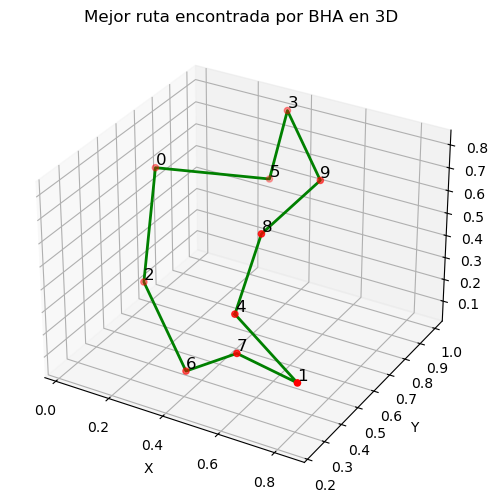

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def distance(point1, point2):
    return np.linalg.norm(point1 - point2)

def total_distance(path, points):
    return sum(distance(points[path[i]], points[path[i + 1]]) for i in range(len(path) - 1)) + distance(points[path[-1]], points[path[0]])

def initialize_population(size, n_points):
    return [np.random.permutation(n_points) for _ in range(size)]

def black_hole_algorithm(n_black_holes, points, max_iter):
    n_points = len(points)
    population = initialize_population(n_black_holes, n_points)
    fitness = np.array([total_distance(ind, points) for ind in population])
    best_idx = np.argmin(fitness)
    black_hole = population[best_idx]
    best_fitness = fitness[best_idx]

    for iteration in range(max_iter):
        for i in range(n_black_holes):
            if i == best_idx:
                continue
            new_solution = population[i].copy()
            swap_idx = np.random.choice(n_points, 2, replace=False)
            new_solution[swap_idx] = new_solution[swap_idx[::-1]]
            new_fitness = total_distance(new_solution, points)

            if new_fitness < fitness[i]:
                population[i] = new_solution
                fitness[i] = new_fitness

                if new_fitness < best_fitness:
                    best_fitness = new_fitness
                    black_hole = new_solution
                    best_idx = i

        event_horizon = np.mean(fitness)
        for i in range(n_black_holes):
            if fitness[i] > event_horizon:
                population[i] = np.random.permutation(n_points)
                fitness[i] = total_distance(population[i], points)

    return black_hole, best_fitness

# Parámetros
n_points = 10
points = np.random.rand(n_points, 3)
n_black_holes = 20
max_iter = 100

best_path, best_fit = black_hole_algorithm(n_black_holes, points, max_iter)
print(f"Mejor ruta encontrada: {best_path}, Distancia total: {best_fit}")

# Visualización en 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='red', marker='o')
for i in range(n_points):
    ax.text(points[i, 0], points[i, 1], points[i, 2], str(i), fontsize=12, verticalalignment='bottom')
path = np.append(best_path, best_path[0])
ax.plot(points[path, 0], points[path, 1], points[path, 2], 'g-', linewidth=2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("Mejor ruta encontrada por BHA en 3D")
plt.show()

## Parámetros del Algoritmo del Agujero Negro (BHA)

### **n_black_holes (Número de agujeros negros)**
- **Descripción**: Cantidad de soluciones en la población, cada una representando una posible ruta.  
- **Aumentar**: Mejora la exploración del espacio de búsqueda, pero incrementa el tiempo de ejecución.  
- **Disminuir**: Reduce el tiempo de ejecución, pero puede disminuir la diversidad de soluciones, lo que puede llevar a un estancamiento en óptimos locales.  

### **n_points (Número de puntos)**
- **Descripción**: Cantidad de puntos en el espacio que forman el problema del viajante.  
- **Aumentar**: Incrementa la complejidad del problema y el tiempo de ejecución.  
- **Disminuir**: Reduce la dificultad del problema, lo que puede hacer que las soluciones óptimas sean más fáciles de encontrar.  

### **max_iter (Número máximo de iteraciones)**
- **Descripción**: Número de ciclos en los que se ejecuta el algoritmo.  
- **Aumentar**: Permite que el algoritmo refine más las soluciones, mejorando la calidad de la mejor ruta encontrada, pero aumenta el tiempo de ejecución.  
- **Disminuir**: Reduce el tiempo de ejecución, pero puede hacer que el algoritmo no tenga suficiente tiempo para encontrar una buena solución.  

### **black_hole (Mejor solución actual)**
- **Descripción**: Es la mejor ruta encontrada hasta el momento en el algoritmo.  
- **Aumentar (mejorar la solución)**: Se logra cuando el algoritmo encuentra una ruta de menor distancia.  
- **Disminuir (peor solución)**: Ocurre cuando la exploración es insuficiente y el algoritmo queda atrapado en soluciones subóptimas.  

### **event_horizon (Horizonte de eventos)**
- **Descripción**: Valor medio de la aptitud (fitness) de las soluciones. Si una solución tiene una aptitud peor que este umbral, se reemplaza por una nueva solución aleatoria.  
- **Aumentar**: Hace que más soluciones sean reemplazadas, promoviendo la exploración del espacio de búsqueda, pero puede impedir la explotación de buenas soluciones.  
- **Disminuir**: Mantiene soluciones durante más tiempo, favoreciendo la explotación, pero puede llevar a estancamientos prematuros en soluciones subóptimas.  

---

En general, estos parámetros deben equilibrarse para lograr un buen compromiso entre **exploración** (buscar nuevas soluciones) y **explotación** (refinar las mejores soluciones encontradas).
